# Setup

## Imports

In [555]:
import pathlib
from typing import Tuple, Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split, KFold, cross_val_score
# from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression

## Shuffle Reproducabity

Without random_state, you'd get a different split each run, producing different train/test sets and therefore different model metrics each time. Passing RANDOM_STATE makes it reproducible. This applies to sklearn `train_test_split`.

`np.random.seed(RANDOM_STATE)` seeds NumPy's global RNG. It matters when using `np.random.*` functions directly (e.g., `np.random.shuffle`, `np.random.choice`).

In [480]:
RANDOM_STATE: int = 42  # global seed for full reproducibility
np.random.seed(RANDOM_STATE)

## Utils

### General

In [481]:
def dummy_error_to_stop_runs() -> None:
  """A dummy function that raises an error to stop the notebook from running further."""
  raise RuntimeError("This is a dummy error to stop the notebook from running further. Please remove this function call to continue.")

def show_columns_with_missing_values(df: pd.DataFrame) -> List[str]:
  """Print the columns in the DataFrame that contain missing values and the number of missing values in each.
  
  Returns
  -------
    List[str]
        A list of column names that contain missing values.
  """

  missing = df.isna().sum()[df.isna().sum() > 0]
  print("Columns with missing values:")
  print(missing)
  return missing.index.tolist()

def show_count_of_columns_missing_values(df: pd.DataFrame, columns: list) -> None:
    """Display the count of missing values for specified columns.
    
    # any row where *either* is NaN will also produce NaN in a custom feature dependent on these columns.
    
    """
    print(df[columns].isna().sum())

def check_columns_for_nulls(df: pd.DataFrame) -> None:
  """Check for null values in the DataFrame and print the columns that contain them."""
  print(df.isnull().any())

def check_columns_for_na(df: pd.DataFrame) -> None:
  """Check for NA values in the DataFrame and print the columns that contain them."""
  # print(df.isna().any())
  print(df.isna().sum())

def check_columns_for_inf(df: pd.DataFrame) -> List[str]:
  """Check for infinite values in the DataFrame and print the columns that contain them."""
  numeric = df.select_dtypes(include='number')

  print("Positive inf counts:")
  print((numeric == np.inf).sum())

  print("\nNegative inf counts:")
  print((numeric == -np.inf).sum())

  # Build list of numeric columns that contain +inf or -inf
  inf_mask = np.isinf(df.select_dtypes(include='number')).any(axis=0)
  columns_with_inf = inf_mask[inf_mask].index.tolist()

  print("Columns with inf values:", columns_with_inf)

  return columns_with_inf

def check_dataset_size_and_shape(df: pd.DataFrame):
  print(f"Number of rows: {len(df)}")
  print(f"Dataset shape: {df.shape}")
  print(f"Number of rows (alternative): {df.shape[0]}")




### Mutations

In [482]:
def remove_rows_with_inf(df: pd.DataFrame, columns: List[str]) -> pd.DataFrame:
    """Remove rows from the DataFrame where any of the specified columns contain positive or negative infinity values.
    
    Parameters
    ----------
    df : pd.DataFrame
        The DataFrame to clean.
    columns : List[str]
        A list of column names to check for infinity values.

    Returns
    -------
    pd.DataFrame
        A new DataFrame with rows containing infinity values in the specified columns removed.

        Then remove 'Death_Ratio' from exclude and it participates normally
    
    """
    for col in columns:
        df = df[df[col] != np.inf]
        df = df[df[col] != -np.inf]
    return df


def apply_iqr_outlier_removal(df: pd.DataFrame, numeric_cols: List[str], exclude: set[str]) -> pd.DataFrame:
    """Apply IQR outlier removal to the DataFrame, excluding specified columns.
    
    Parameters
    ----------
    df : pd.DataFrame
        The DataFrame containing the data.
    numeric_cols : List[str]
        A list of numeric column names to consider for outlier removal.
    exclude : set
        A set of column names to exclude from outlier removal.

    Returns
    -------
    pd.DataFrame
        A new DataFrame with outliers removed based on the IQR method, excluding specified columns.
    
    Notes:
    - Only applies IQR to numeric columns that are not in the exclude set.
    - Prints the number of rows removed and the before/after row counts.
    """
    # Only apply IQR to meaningful feature columns
    outlier_cols = [col for col in numeric_cols if col not in exclude]

    rows_before = len(df)

    for col in outlier_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        df = df[(df[col] >= lower) & (df[col] <= upper)]

    rows_after = len(df)
    print(f"Rows removed: {rows_before - rows_after}  ({rows_before} → {rows_after})")
    return df
  

### Tests

In [545]:
def test_no_missing_values(df: pd.DataFrame, columns: list) -> None:
  """Assert that there are no missing values in the specified columns.
  
  The double .sum() first sums per column, then sums across all specified columns into one total. If that total is not zero, the assert raises an AssertionError with the message. If the cell runs silently, all specified columns are clean.
  """
  assert df[columns].isna().sum().sum() == 0, f"Missing values found in {', '.join(columns)}"

def test_no_inf_columns(columns_with_inf: list) -> None:
  """Assert that no numeric columns contain +inf or -inf."""
  assert len(columns_with_inf) == 0, f"Columns still containing inf values: {columns_with_inf}"

def test_train_test_split_ratio(df: pd.DataFrame, X_train, X_test, expected_test_size: float = 0.25, tolerance: float = 0.01) -> None:
    """Assert that the train/test split is approximately the expected ratio."""
    check_dataset_size_and_shape(df)

    total = len(X_train) + len(X_test)
    actual_test_ratio = len(X_test) / total
    print(f"Train size: {len(X_train)}, Test size: {len(X_test)}, Test ratio: {actual_test_ratio:.2%}")
    assert abs(actual_test_ratio - expected_test_size) <= tolerance, (
        f"Expected test ratio ~{expected_test_size:.0%}, got {actual_test_ratio:.2%}"
    )
  
def test_only_non_numeric_columns(df: pd.DataFrame) -> None:
  """Assert that all columns in df are non-numeric.

  Not used for linear regression, but could be useful for verifying that feature selection has successfully removed all numeric columns, leaving only categorical features.
  
  Useful for verifying that all numeric columns have been dropped during feature selection, leaving only non-numeric columns (e.g., categorical features) in the DataFrame. If any numeric columns are found, the assert will raise an AssertionError with the list of offending columns. If the cell runs without error, it confirms that all columns are non-numeric as expected.
  """
  numeric_cols = df.select_dtypes(include="number").columns.tolist()
  assert len(numeric_cols) == 0, f"Numeric columns found: {numeric_cols}"
  print("All columns are non-numeric.")

def test_only_numeric_columns(df: pd.DataFrame) -> None:
  """Assert that all columns in df are numeric only.
  
  This is important for linear regression, which requires numeric input features. If any non-numeric columns are found, the assert will raise an AssertionError with the list of offending columns. If the cell runs without error, it confirms that all columns are numeric as expected.

  """
  numeric_cols = df.select_dtypes(include="number").columns.tolist()
  assert len(numeric_cols) == len(df.columns), f"Non-numeric columns found: {set(df.columns) - set(numeric_cols)}"
  print("All columns are numeric.")


### Plots

In [484]:

def plot_predictors_vs_target(df: pd.DataFrame, target: str) -> None:
    """Plot scatter plots of all numeric predictors against the target variable.
    
    Parameters
    ----------
    df : pd.DataFrame
        The DataFrame containing the data.
    target : str
        The name of the target variable column.

    Returns
    -------
    None
        Displays scatter plots of each numeric predictor against the target variable.


    Notes:
    - Automatically selects all numeric columns except the target Life expectancy
    - Lays them out in a 4-column grid
    - Uses alpha=0.3 and small point size to handle overplotting on the ~1600-row dataset
    - Hides leftover empty subplot panels

    """
    predictors = df.select_dtypes(include='number').columns.drop(target).tolist()
      
    n_cols = 4
    n_rows = -(-len(predictors) // n_cols)  # ceiling division

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
    axes = axes.flatten()

    for i, col in enumerate(predictors):
        axes[i].scatter(df[col], df[target], alpha=0.3, s=10)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel(target)
        axes[i].set_title(f'{col} vs {target}')

    # Hide any unused axes
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()


def plot_boxplots_of_numeric_features(df: pd.DataFrame, subtitle: str = 'Box-Whisker Plots (pre-removal)') -> List[str]:
    """Plot boxplots of all numeric features to visually inspect for outliers.
    
    Parameters
    ----------
    df : pd.DataFrame
      The DataFrame containing the data.

    Returns
    -------
      Displays boxplots of all numeric features in a grid layout.

      List of numeric columns is automatically determined, and the boxplots are arranged in a 4-column grid. Leftover empty subplot panels are hidden.
    
    """
    numeric_cols = df.select_dtypes(include='number').columns.tolist()

    n_cols = 4
    n_rows = -(-len(numeric_cols) // n_cols)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 4))
    axes = axes.flatten()

    for i, col in enumerate(numeric_cols):
        axes[i].boxplot(df[col].dropna(), vert=True, patch_artist=True)
        axes[i].set_title(col, fontsize=9)
        axes[i].set_xticks([])

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(subtitle, fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

    return numeric_cols

## Load Dataset

In [485]:

_DATA_PATH = pathlib.Path("Life_Expectancy_Data.csv")
if not _DATA_PATH.exists():
    raise FileNotFoundError(
        "Life_Expectancy_Data.csv is missing from the lab directory. Please download it or ask the TA "
        "for assistance."
    )

In [486]:


def load_dataset() -> pd.DataFrame:
    """Load the Life Expectancy data from ``Life_Expectancy_Data.csv``.

    Strip any leading or trailing whitespace from the column names to ensure they are clean and consistent.

    Returns
    -------
    pd.DataFrame
        A DataFrame containing data.
    """
    df = pd.read_csv('Life_Expectancy_Data.csv')
    df.columns = df.columns.str.strip()
    return df


# Compute the answer required by the autograder
q1_shape: Tuple[int, int] = load_dataset().shape

In [487]:

df = load_dataset()



# Exploratory Data Analysis (EDA)

## General

In [488]:
check_dataset_size_and_shape(df)

Number of rows: 2938
Dataset shape: (2938, 22)
Number of rows (alternative): 2938


In [489]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2938 entries, 0 to 2937
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Country                          2938 non-null   str    
 1   Year                             2938 non-null   int64  
 2   Status                           2938 non-null   str    
 3   Life expectancy                  2928 non-null   float64
 4   Adult Mortality                  2928 non-null   float64
 5   infant deaths                    2938 non-null   int64  
 6   Alcohol                          2744 non-null   float64
 7   percentage expenditure           2938 non-null   float64
 8   Hepatitis B                      2385 non-null   float64
 9   Measles                          2938 non-null   int64  
 10  BMI                              2904 non-null   float64
 11  under-five deaths                2938 non-null   int64  
 12  Polio                          

In [490]:
df.describe()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.000000,2928.000000,2928.000000,2938.000000,2744.000000,2938.000000,2385.000000,2938.000000,2904.000000,2938.000000,2919.000000,2712.00000,2919.000000,2938.000000,2490.000000,2.286000e+03,2904.000000,2904.000000,2771.000000,2775.000000
mean,2007.518720,69.224932,164.796448,30.303948,4.602861,738.251295,80.940461,2419.592240,38.321247,42.035739,82.550188,5.93819,82.324084,1.742103,7483.158469,1.275338e+07,4.839704,4.870317,0.627551,11.992793
std,4.613841,9.523867,124.292079,117.926501,4.052413,1987.914858,25.070016,11467.272489,20.044034,160.445548,23.428046,2.49832,23.716912,5.077785,14270.169342,6.101210e+07,4.420195,4.508882,0.210904,3.358920
min,2000.000000,36.300000,1.000000,0.000000,0.010000,0.000000,1.000000,0.000000,1.000000,0.000000,3.000000,0.37000,2.000000,0.100000,1.681350,3.400000e+01,0.100000,0.100000,0.000000,0.000000
25%,2004.000000,63.100000,74.000000,0.000000,0.877500,4.685343,77.000000,0.000000,19.300000,0.000000,78.000000,4.26000,78.000000,0.100000,463.935626,1.957932e+05,1.600000,1.500000,0.493000,10.100000
50%,2008.000000,72.100000,144.000000,3.000000,3.755000,64.912906,92.000000,17.000000,43.500000,4.000000,93.000000,5.75500,93.000000,0.100000,1766.947595,1.386542e+06,3.300000,3.300000,0.677000,12.300000
75%,2012.000000,75.700000,228.000000,22.000000,7.702500,441.534144,97.000000,360.250000,56.200000,28.000000,97.000000,7.49250,97.000000,0.800000,5910.806335,7.420359e+06,7.200000,7.200000,0.779000,14.300000
max,2015.000000,89.000000,723.000000,1800.000000,17.870000,19479.911610,99.000000,212183.000000,87.300000,2500.000000,99.000000,17.60000,99.000000,50.600000,119172.741800,1.293859e+09,27.700000,28.600000,0.948000,20.700000


In [491]:
df.head()

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


## Missing Data e.g. NaN, nulls, etc

In [492]:
print(df['Population'].isna().sum())
print(df['Population'].value_counts(dropna=False))

652
Population
NaN           652
444.0           4
1141.0          2
127445.0        2
718239.0        2
             ... 
12777511.0      1
12633897.0      1
125525.0        1
12366165.0      1
12222251.0      1
Name: count, Length: 2279, dtype: int64


In [493]:
check_columns_for_nulls(df)

Country                            False
Year                               False
Status                             False
Life expectancy                     True
Adult Mortality                     True
infant deaths                      False
Alcohol                             True
percentage expenditure             False
Hepatitis B                         True
Measles                            False
BMI                                 True
under-five deaths                  False
Polio                               True
Total expenditure                   True
Diphtheria                          True
HIV/AIDS                           False
GDP                                 True
Population                          True
thinness  1-19 years                True
thinness 5-9 years                  True
Income composition of resources     True
Schooling                           True
dtype: bool


In [494]:
check_columns_for_na(df)

Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
BMI                                 34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
HIV/AIDS                             0
GDP                                448
Population                         652
thinness  1-19 years                34
thinness 5-9 years                  34
Income composition of resources    167
Schooling                          163
dtype: int64


In [495]:
columns_with_missing_values_list = show_columns_with_missing_values(df)

Columns with missing values:
Life expectancy                     10
Adult Mortality                     10
Alcohol                            194
Hepatitis B                        553
BMI                                 34
Polio                               19
Total expenditure                  226
Diphtheria                          19
GDP                                448
Population                         652
thinness  1-19 years                34
thinness 5-9 years                  34
Income composition of resources    167
Schooling                          163
dtype: int64


# Preprocessing

## Dropping

In [496]:
# drop rows with no population data
# @see https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html#pandas.DataFrame.dropna
# df = df.dropna(subset=['Population','Alcohol', 'BMI'])
df = df.dropna(subset=columns_with_missing_values_list)

## Imputing

## Confirm

In [497]:
show_columns_with_missing_values(df)

Columns with missing values:
Series([], dtype: int64)


[]

# Feature Engineering

## Population Size 

In [498]:
bins = [0, 1_000, 30_000, 100_000, float('inf')]
labels = ['Under 1K', 'Small', 'Medium', 'Large']

df['Population Size'] = pd.cut(
    df['Population'],
    bins=bins,
    labels=labels,
    right=False
)

print(df['Population Size'].value_counts(dropna=False))
df.head()


Population Size
Large       1337
Small        160
Medium       127
Under 1K      25
Name: count, dtype: int64


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,Population Size
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1,Large
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0,Large
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9,Large
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8,Large
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5,Large


In [499]:
show_count_of_columns_missing_values(df, ['Population', 'Population Size'])

Population         0
Population Size    0
dtype: int64


In [500]:
test_no_missing_values(df, ['Population', 'Population Size'])

## Lifestyle

Lifestyle – Create a lifestyle feature that combines alcohol consumption and BMI. 

In [501]:
df['Lifestyle'] = df['Alcohol'] * df['BMI']

df[['Alcohol', 'BMI', 'Lifestyle']].head()

,Alcohol,BMI,Lifestyle
0,0.01,19.1,0.191
1,0.01,18.6,0.186
2,0.01,18.1,0.181
3,0.01,17.6,0.176
4,0.01,17.2,0.172


In [502]:
# any row where *either* is NaN will also produce NaN in Lifestyle.
df[['Alcohol', 'BMI', 'Lifestyle']].isna().sum()

Alcohol      0
BMI          0
Lifestyle    0
dtype: int64

In [503]:
show_count_of_columns_missing_values(df, ['Alcohol', 'BMI', 'Lifestyle'])

Alcohol      0
BMI          0
Lifestyle    0
dtype: int64


In [504]:
test_no_missing_values(df, ['Alcohol', 'BMI', 'Lifestyle'])

## Economy

Economy – Create an economy feature that combines population and GDP. 

In [505]:
df[['Population', 'GDP']].head()

,Population,GDP
0,33736494.0,584.259210
1,327582.0,612.696514
2,31731688.0,631.744976
3,3696958.0,669.959000
4,2978599.0,63.537231


In [506]:
df['Economy'] = df['Population'] * df['GDP']

df[['Population', 'GDP', 'Economy']].head()

,Population,GDP,Economy
0,33736494.0,584.259210,1.971086e+10
1,327582.0,612.696514,2.007083e+08
2,31731688.0,631.744976,2.004633e+10
3,3696958.0,669.959000,2.476810e+09
4,2978599.0,63.537231,1.892519e+08


In [507]:
show_count_of_columns_missing_values(df, ['Population', 'GDP', 'Economy'])


Population    0
GDP           0
Economy       0
dtype: int64


In [508]:
test_no_missing_values(df, ['Population', 'GDP', 'Economy'])

## Death Ratio

Death Ratio – Determine the death ratio between adult and infant mortality. 

In [509]:
df[['Adult Mortality', 'infant deaths']].head()

,Adult Mortality,infant deaths
0,263.0,62
1,271.0,64
2,268.0,66
3,272.0,69
4,275.0,71


In [510]:
df['Death_Ratio'] = df['Adult Mortality'] / df['infant deaths']

df[['Adult Mortality', 'infant deaths', 'Death_Ratio']].head()

,Adult Mortality,infant deaths,Death_Ratio
0,263.0,62,4.241935
1,271.0,64,4.234375
2,268.0,66,4.060606
3,272.0,69,3.942029
4,275.0,71,3.873239


In [511]:
show_count_of_columns_missing_values(df, ['Adult Mortality', 'infant deaths', 'Death_Ratio'])


Adult Mortality    0
infant deaths      0
Death_Ratio        0
dtype: int64


In [512]:
test_no_missing_values(df, ['Adult Mortality', 'infant deaths', 'Death_Ratio'])

# 2nd Exploratory Data Analysis (EDA)

Check All Again

## General

In [538]:
check_dataset_size_and_shape(df)

Number of rows: 256
Dataset shape: (256, 25)
Number of rows (alternative): 256


In [513]:
df.info()

<class 'pandas.DataFrame'>
Index: 1649 entries, 0 to 2937
Data columns (total 26 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   Country                          1649 non-null   str     
 1   Year                             1649 non-null   int64   
 2   Status                           1649 non-null   str     
 3   Life expectancy                  1649 non-null   float64 
 4   Adult Mortality                  1649 non-null   float64 
 5   infant deaths                    1649 non-null   int64   
 6   Alcohol                          1649 non-null   float64 
 7   percentage expenditure           1649 non-null   float64 
 8   Hepatitis B                      1649 non-null   float64 
 9   Measles                          1649 non-null   int64   
 10  BMI                              1649 non-null   float64 
 11  under-five deaths                1649 non-null   int64   
 12  Polio                 

In [514]:
check_columns_for_nulls(df)

Country                            False
Year                               False
Status                             False
Life expectancy                    False
Adult Mortality                    False
infant deaths                      False
Alcohol                            False
percentage expenditure             False
Hepatitis B                        False
Measles                            False
BMI                                False
under-five deaths                  False
Polio                              False
Total expenditure                  False
Diphtheria                         False
HIV/AIDS                           False
GDP                                False
Population                         False
thinness  1-19 years               False
thinness 5-9 years                 False
Income composition of resources    False
Schooling                          False
Population Size                    False
Lifestyle                          False
Economy         

In [515]:
check_columns_for_na(df)

Country                            0
Year                               0
Status                             0
Life expectancy                    0
Adult Mortality                    0
infant deaths                      0
Alcohol                            0
percentage expenditure             0
Hepatitis B                        0
Measles                            0
BMI                                0
under-five deaths                  0
Polio                              0
Total expenditure                  0
Diphtheria                         0
HIV/AIDS                           0
GDP                                0
Population                         0
thinness  1-19 years               0
thinness 5-9 years                 0
Income composition of resources    0
Schooling                          0
Population Size                    0
Lifestyle                          0
Economy                            0
Death_Ratio                        0
dtype: int64


In [516]:
show_columns_with_missing_values(df)

Columns with missing values:
Series([], dtype: int64)


[]

## Linearality Check

Ordinary Least Squares (OLS) assumes a linear relationship between each predictor and the target. A curved relationship violates that assumption, inflating residuals and reducing R². Transforming the predictor to linearize the relationship lets the model fit it properly.

### Plots

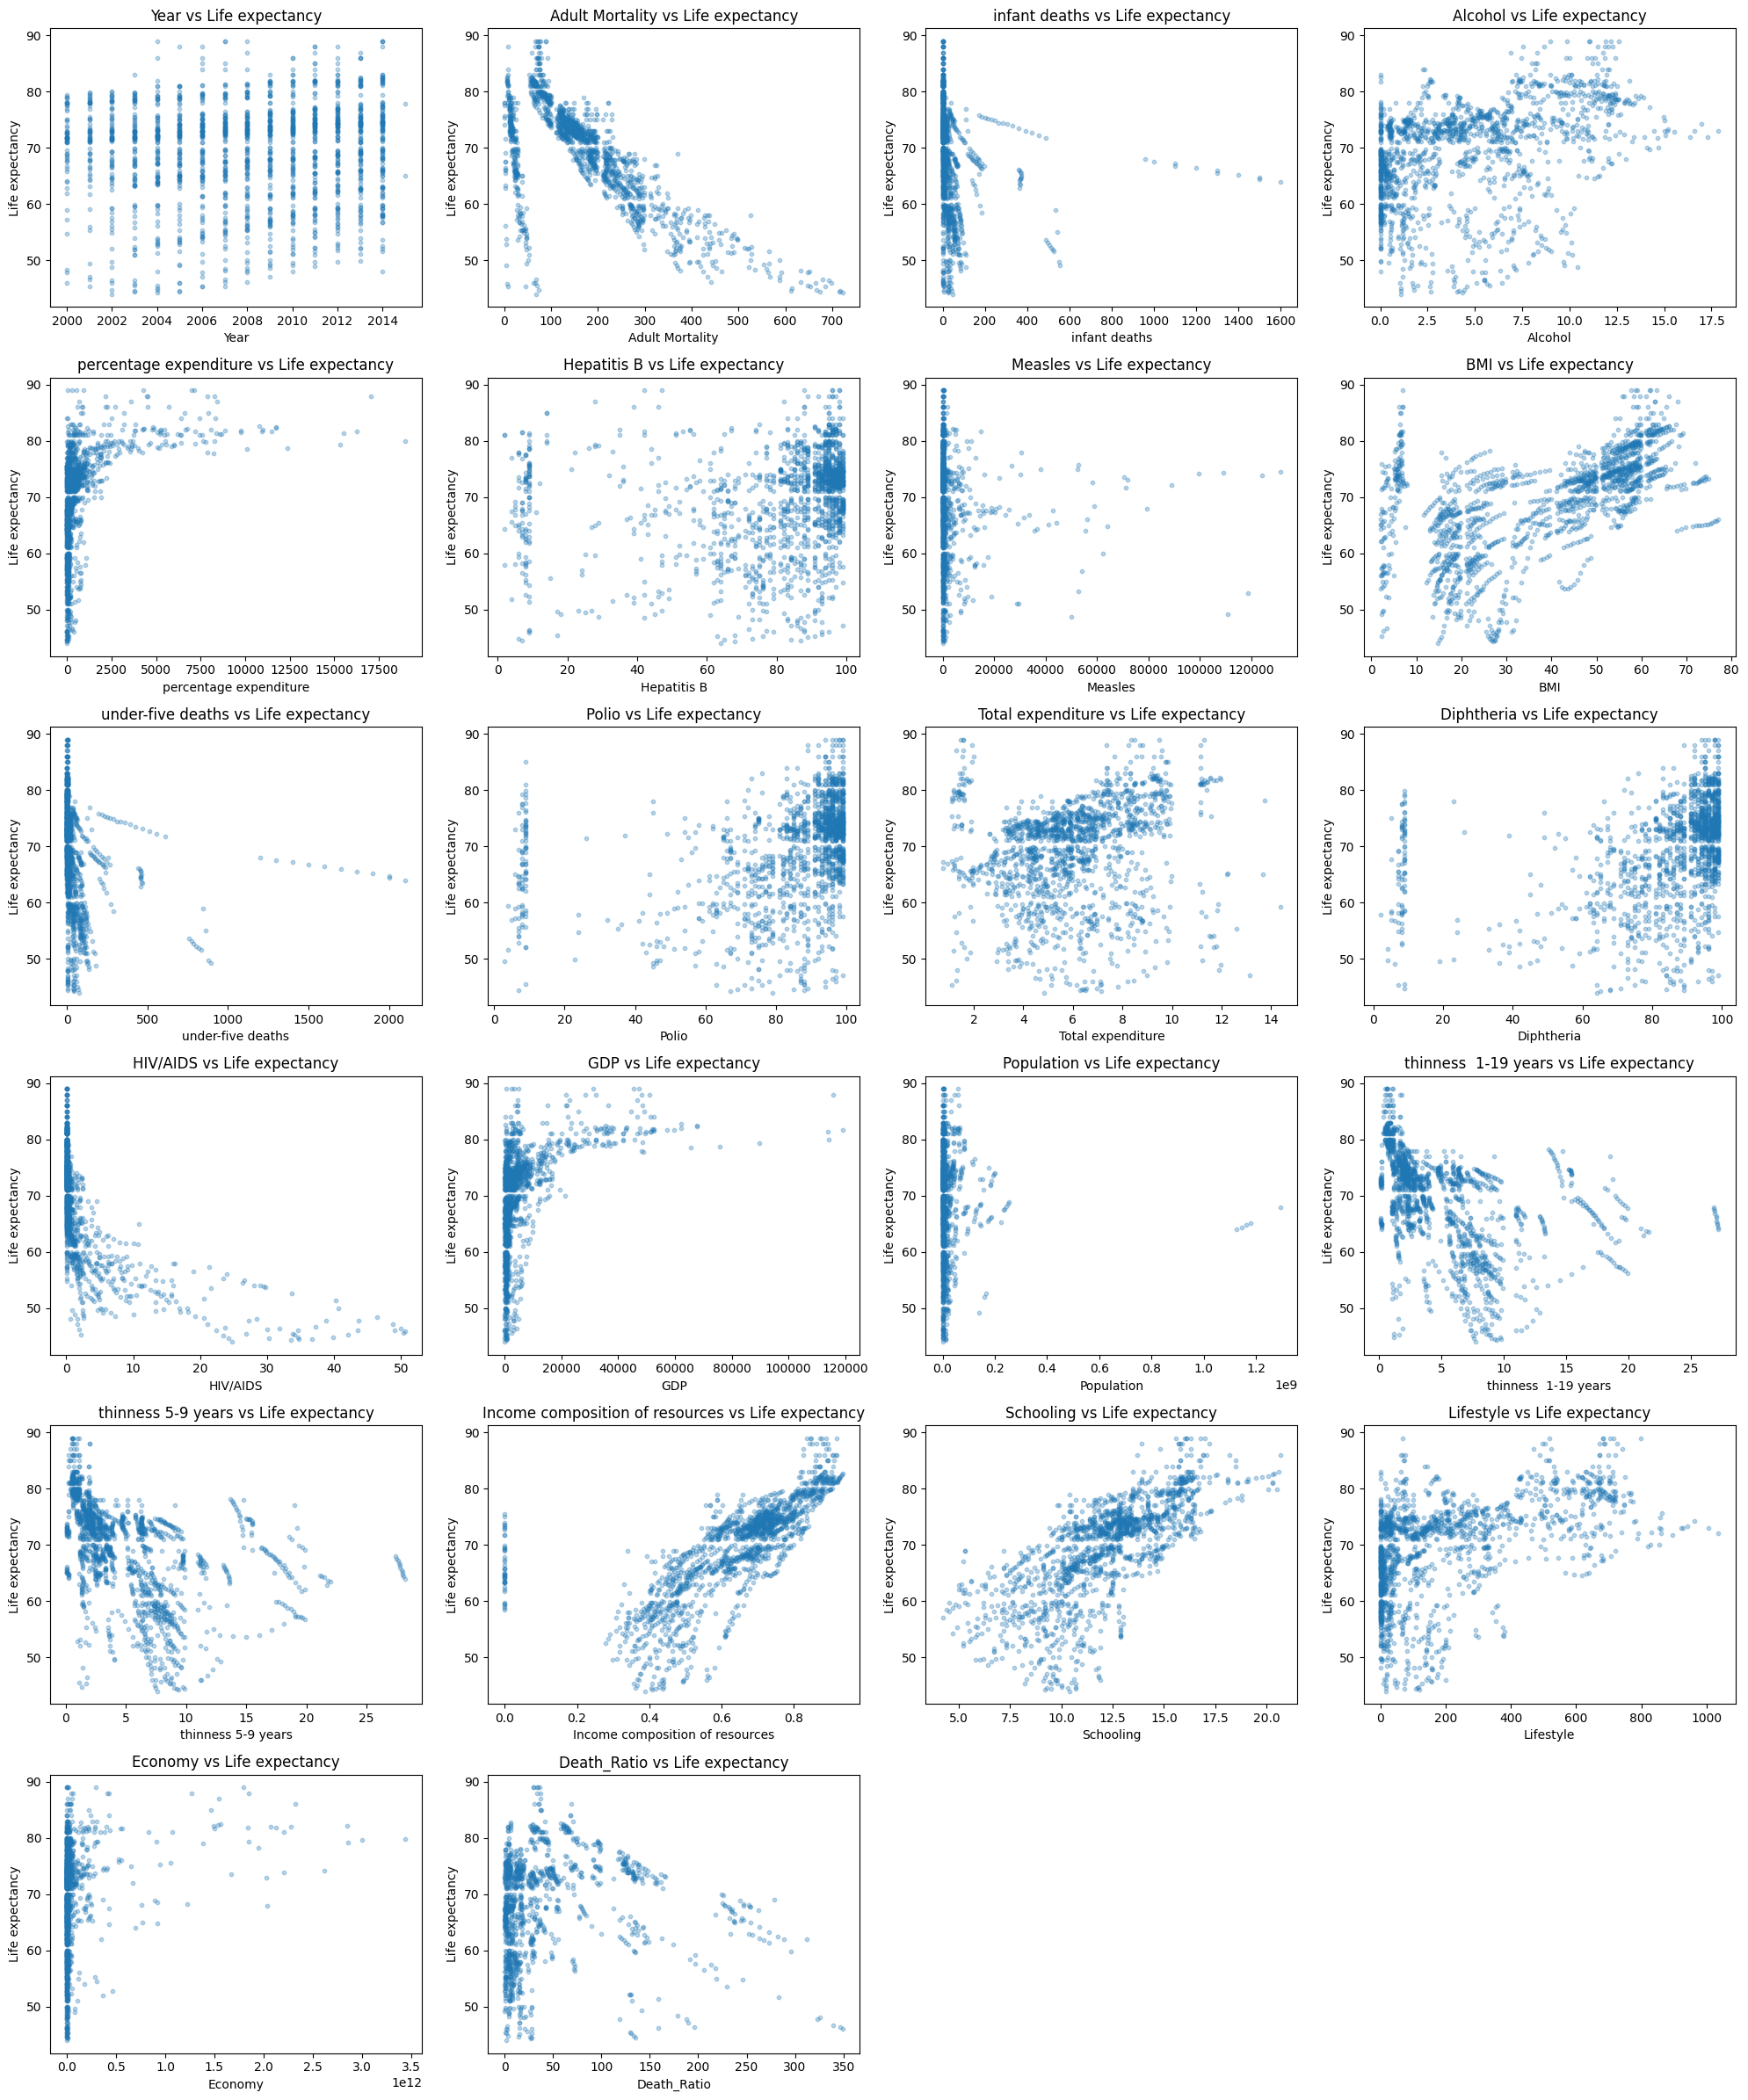

In [517]:

target = 'Life expectancy'

plot_predictors_vs_target(df, target)

## Multi-Collinearity

Redundancy between predictor variables. Meaning two features may be telling the same story about the target and therefore they are highly correlated. 

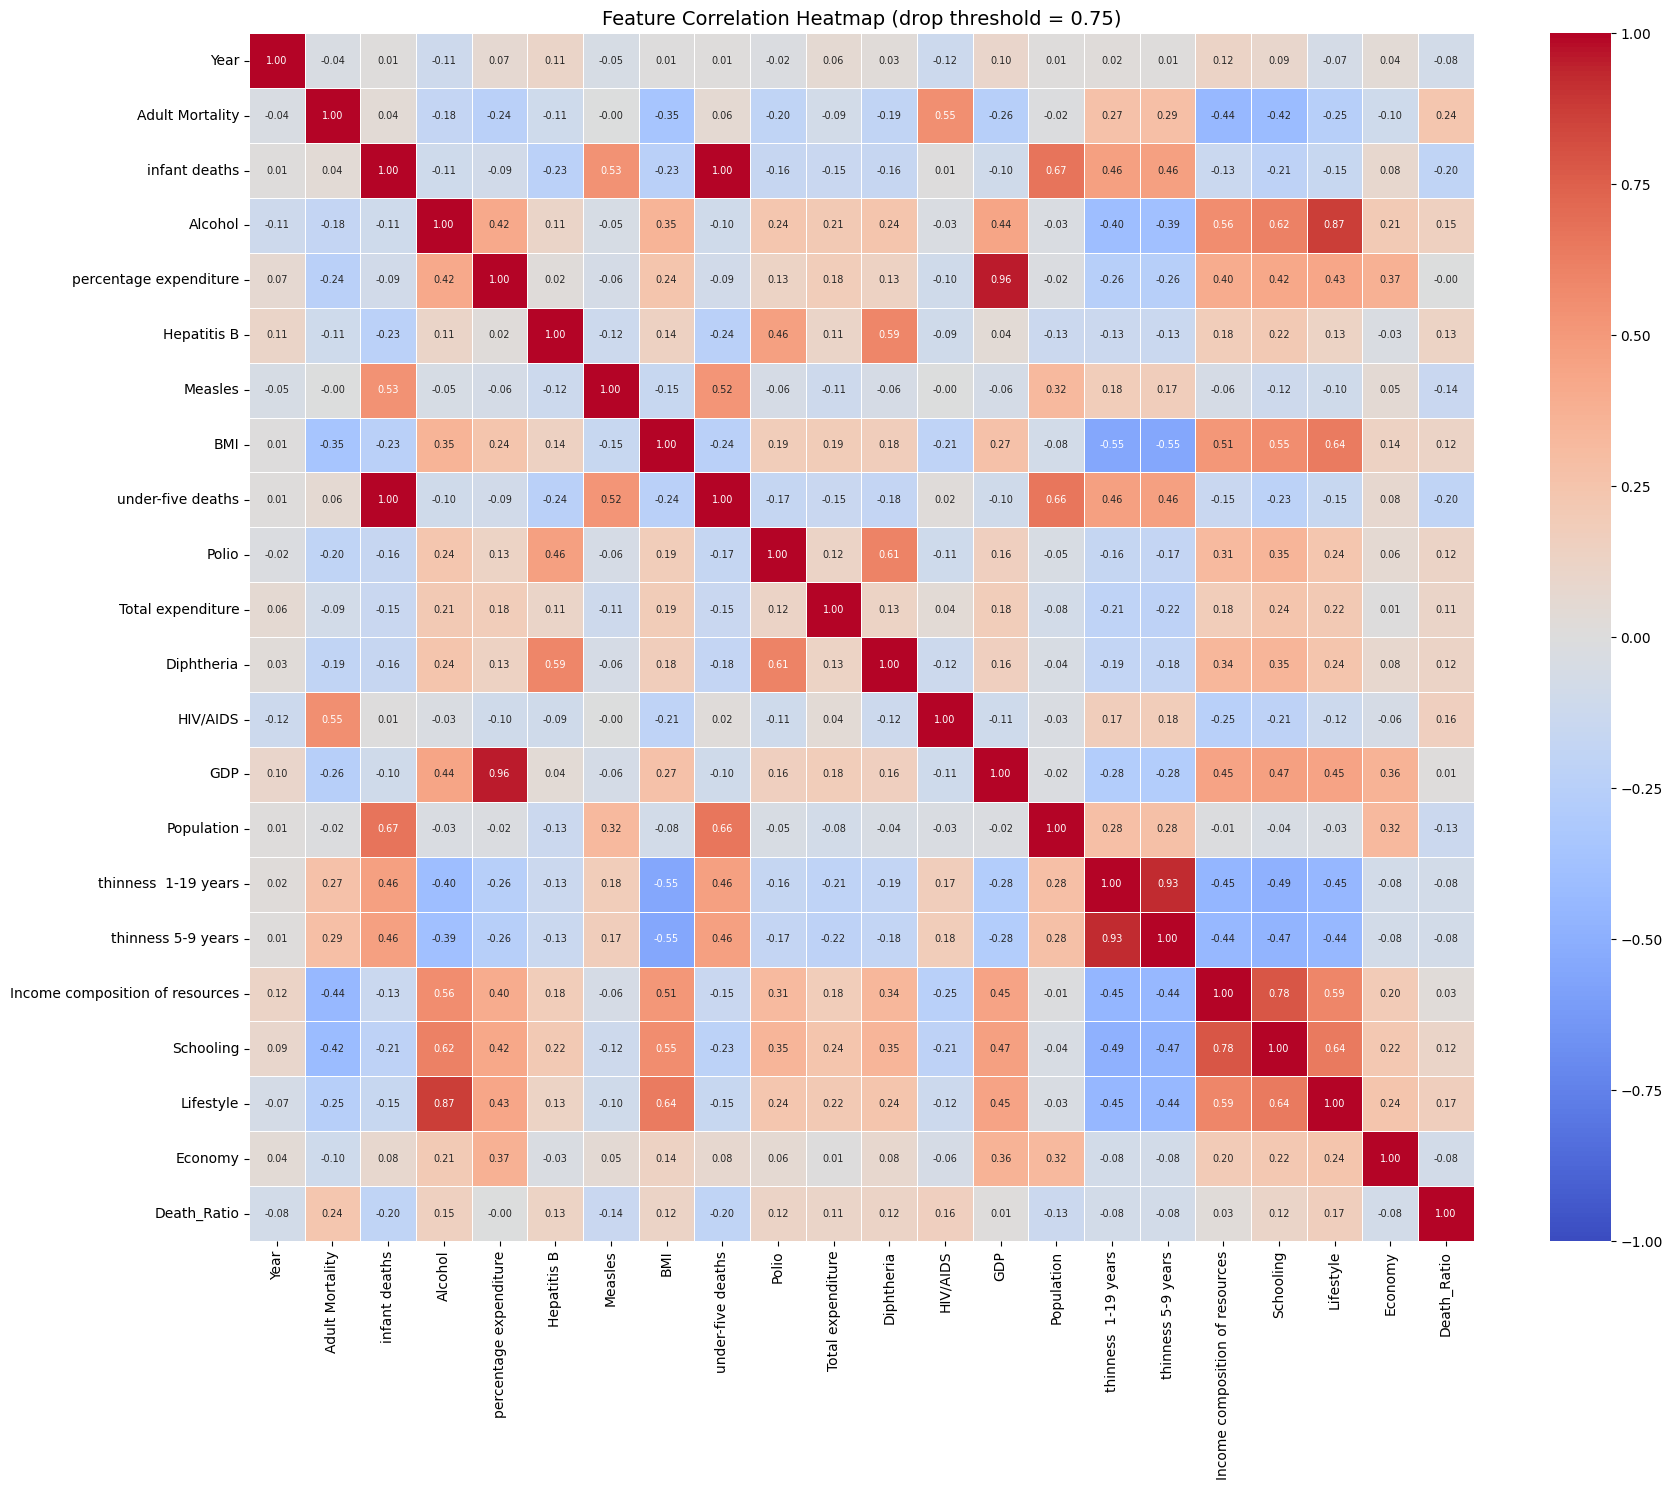

In [518]:
import seaborn as sns

THRESHOLD = 0.75

# Correlation matrix on numeric features only (exclude target)
feature_cols = df.select_dtypes(include='number').columns.drop(target).tolist()
corr_matrix = df[feature_cols].corr()

# Plot heatmap
fig, ax = plt.subplots(figsize=(18, 15))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    annot_kws={'size': 7},
    ax=ax
)
ax.set_title(f'Feature Correlation Heatmap (drop threshold = {THRESHOLD})', fontsize=14)
plt.tight_layout()
plt.show()


## Outliers

Eliminate possible outliers by generating box-whisker plots. 

Box-and-whisker plots serve as a visual companion to the IQR (Interquartile Range) method, allowing to see distribution. 

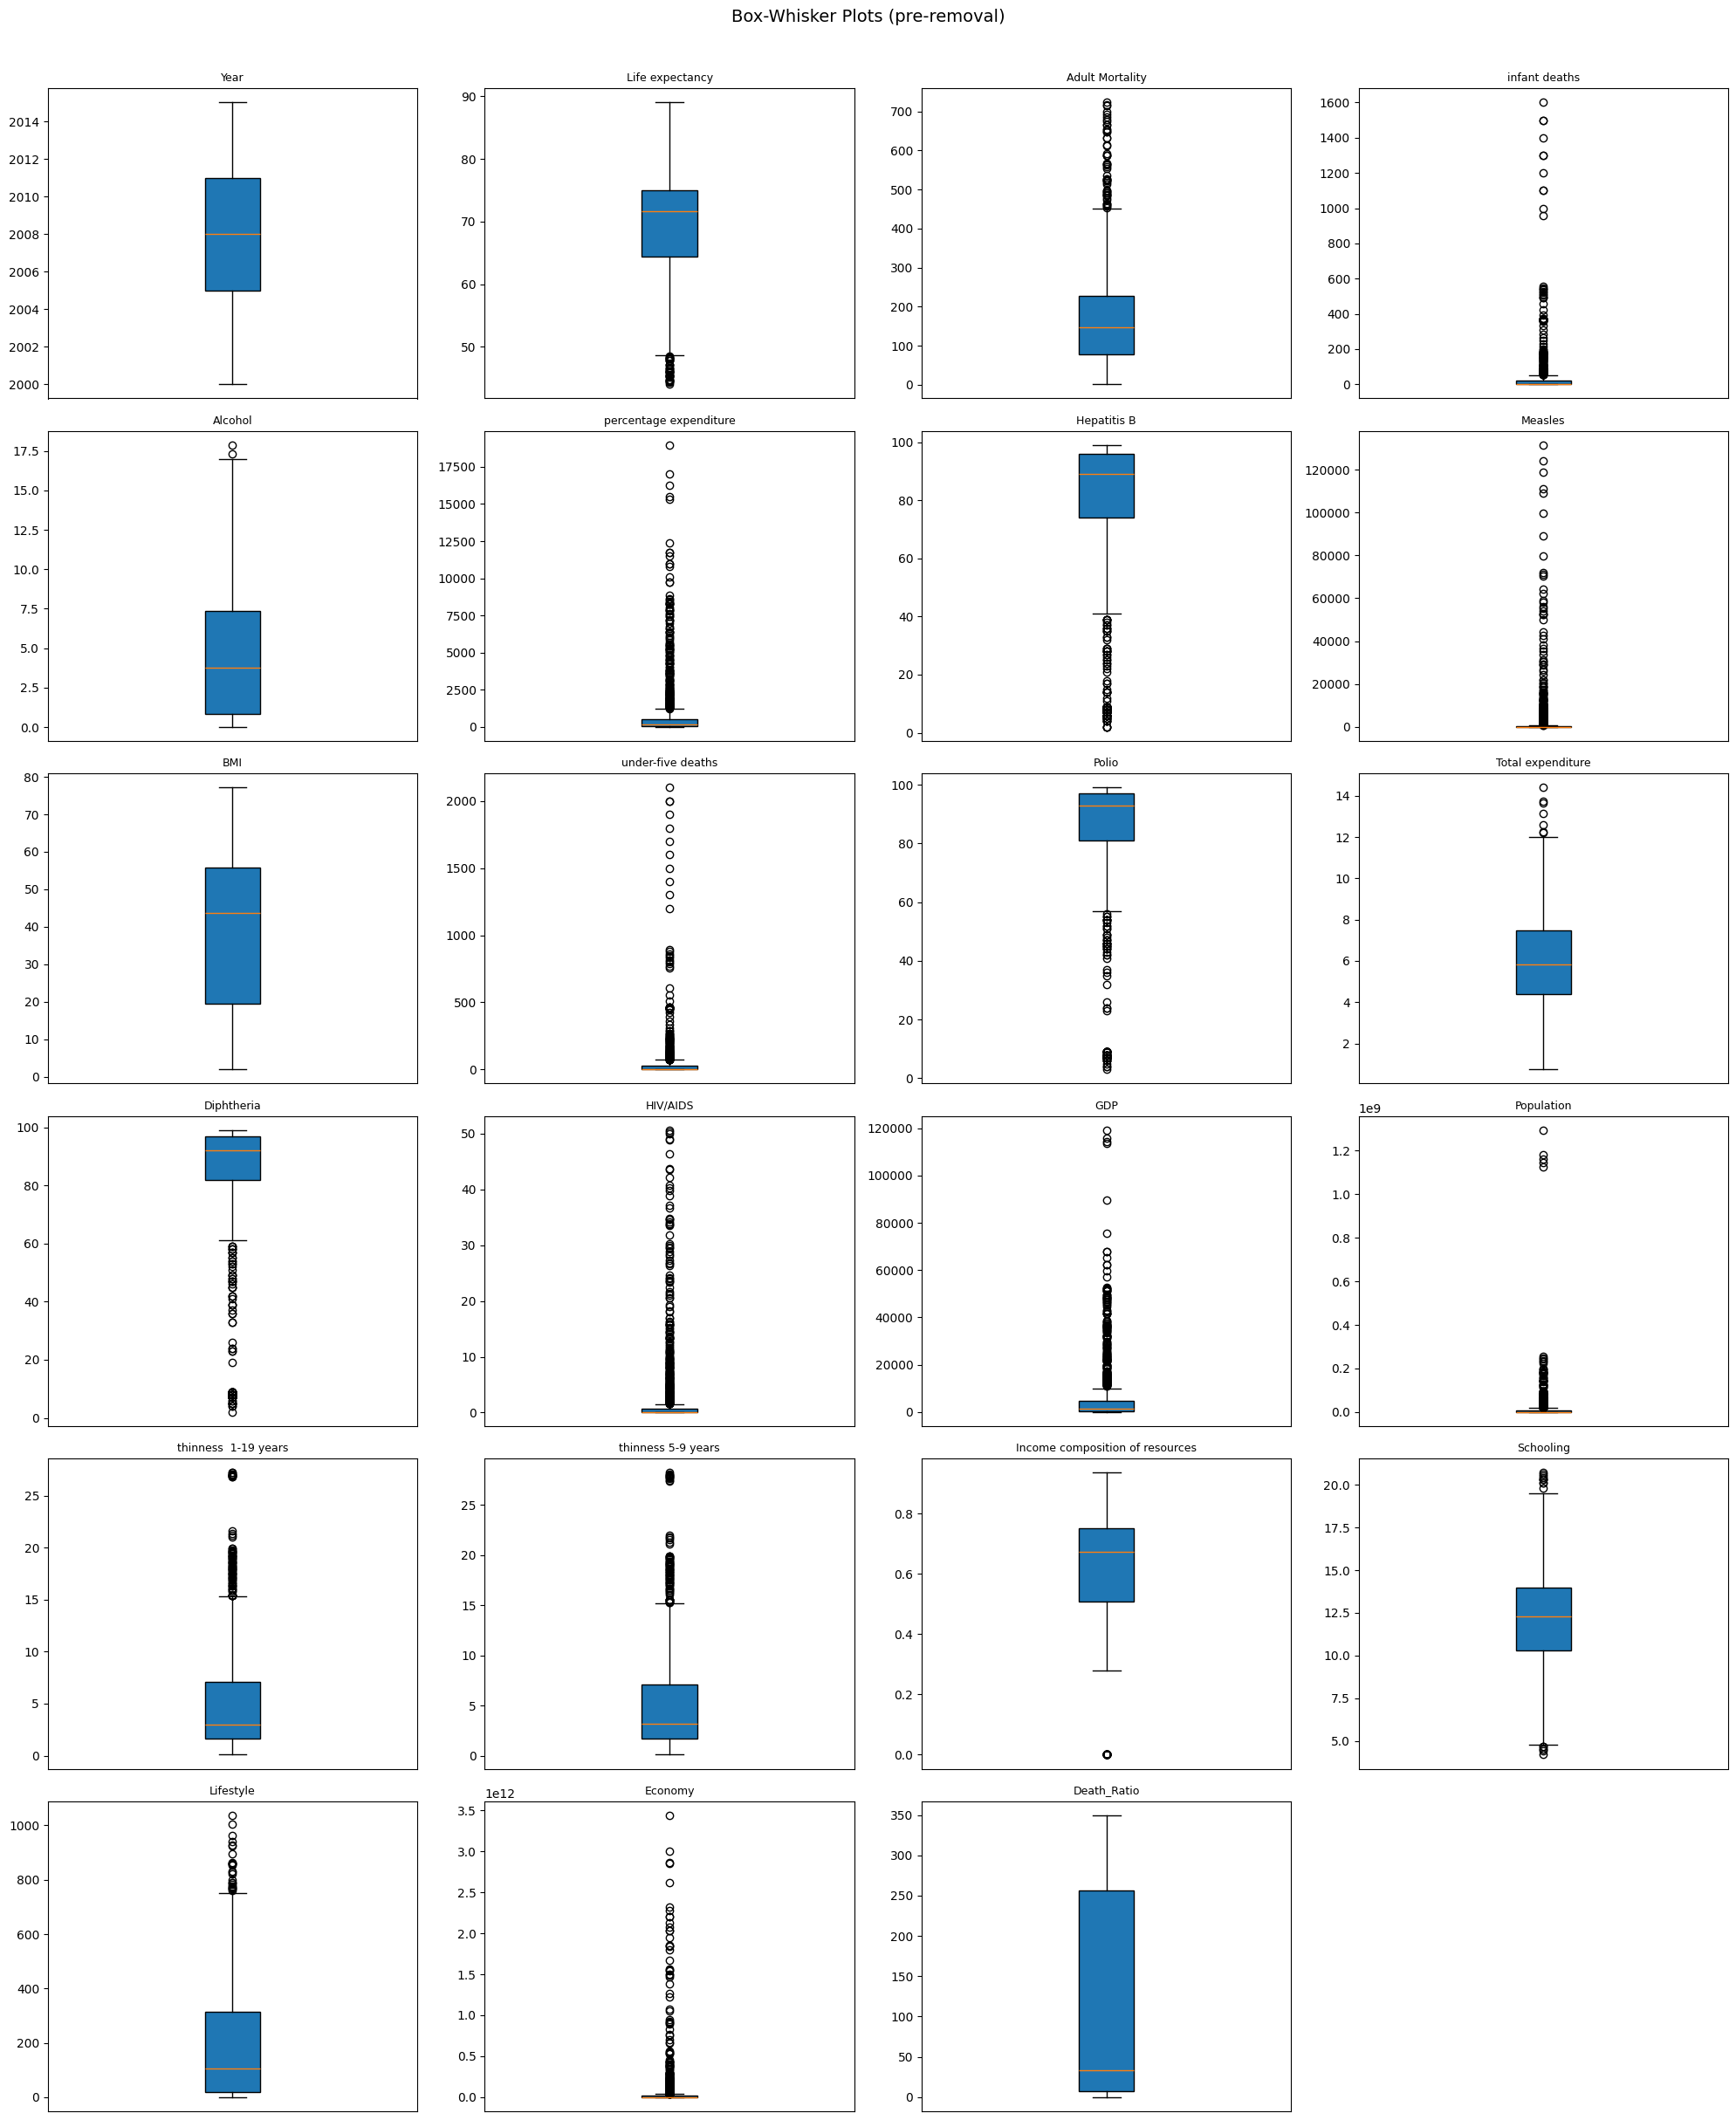

In [519]:
numeric_cols = plot_boxplots_of_numeric_features(df)


## Check Infinites

Initially caught by "Death_Ratio" but could be abstracted to apply to any.

In [520]:
# Check a single column
np.isinf(df['Death_Ratio']).sum()

np.int64(395)

In [521]:
# Check which values are inf (positive or negative)
df[np.isinf(df['Death_Ratio'])]

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling,Population Size,Lifestyle,Economy,Death_Ratio
16,Albania,2015,Developing,77.8,74.0,0,4.60,364.975229,99.0,0,...,3954.227830,28873.0,1.2,1.3,0.762,14.2,Small,266.800,1.141704e+08,inf
17,Albania,2014,Developing,77.5,8.0,0,4.51,428.749067,98.0,0,...,4575.763787,288914.0,1.2,1.3,0.761,14.2,Large,257.972,1.322002e+09,inf
18,Albania,2013,Developing,77.2,84.0,0,4.76,430.876979,99.0,0,...,4414.723140,289592.0,1.3,1.4,0.759,14.2,Large,268.940,1.278469e+09,inf
19,Albania,2012,Developing,76.9,86.0,0,5.14,412.443356,99.0,9,...,4247.614380,2941.0,1.3,1.4,0.752,14.2,Small,286.812,1.249223e+07,inf
20,Albania,2011,Developing,76.6,88.0,0,5.37,437.062100,99.0,28,...,4437.178680,295195.0,1.4,1.5,0.738,13.3,Large,295.887,1.309833e+09,inf
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2853,Vanuatu,2004,Developing,69.6,169.0,0,0.85,334.167337,63.0,0,...,1787.947230,24143.0,1.6,1.5,0.000,10.7,Small,37.485,4.316641e+07,inf
2854,Vanuatu,2003,Developing,69.4,173.0,0,1.20,27.298391,64.0,165,...,158.527240,198964.0,1.6,1.6,0.000,10.4,Large,51.960,3.154121e+07,inf
2855,Vanuatu,2002,Developing,69.3,176.0,0,1.24,171.137361,66.0,101,...,1353.934819,193956.0,1.7,1.6,0.000,10.2,Large,52.824,2.626038e+08,inf
2856,Vanuatu,2001,Developing,69.1,179.0,0,0.91,163.105292,68.0,7,...,1362.617310,18929.0,1.7,1.6,0.000,10.1,Small,38.129,2.579298e+07,inf


In [522]:
# See specific columns for rows where Death_Ratio is inf
cols = ['Country', 'Year', 'Adult Mortality', 'infant deaths', 'Death_Ratio']
df.loc[np.isinf(df['Death_Ratio']), cols]

,Country,Year,Adult Mortality,infant deaths,Death_Ratio
16,Albania,2015,74.0,0,inf
17,Albania,2014,8.0,0,inf
18,Albania,2013,84.0,0,inf
19,Albania,2012,86.0,0,inf
20,Albania,2011,88.0,0,inf
...,...,...,...,...,...
2853,Vanuatu,2004,169.0,0,inf
2854,Vanuatu,2003,173.0,0,inf
2855,Vanuatu,2002,176.0,0,inf
2856,Vanuatu,2001,179.0,0,inf


In [523]:
# Check all numeric columns at once
np.isinf(df.select_dtypes(include='number')).sum()

Year                                 0
Life expectancy                      0
Adult Mortality                      0
infant deaths                        0
Alcohol                              0
percentage expenditure               0
Hepatitis B                          0
Measles                              0
BMI                                  0
under-five deaths                    0
Polio                                0
Total expenditure                    0
Diphtheria                           0
HIV/AIDS                             0
GDP                                  0
Population                           0
thinness  1-19 years                 0
thinness 5-9 years                   0
Income composition of resources      0
Schooling                            0
Lifestyle                            0
Economy                              0
Death_Ratio                        395
dtype: int64

In [524]:
columns_with_inf = check_columns_for_inf(df)

Positive inf counts:
Year                                 0
Life expectancy                      0
Adult Mortality                      0
infant deaths                        0
Alcohol                              0
percentage expenditure               0
Hepatitis B                          0
Measles                              0
BMI                                  0
under-five deaths                    0
Polio                                0
Total expenditure                    0
Diphtheria                           0
HIV/AIDS                             0
GDP                                  0
Population                           0
thinness  1-19 years                 0
thinness 5-9 years                   0
Income composition of resources      0
Schooling                            0
Lifestyle                            0
Economy                              0
Death_Ratio                        395
dtype: int64

Negative inf counts:
Year                               0
Life expec

# 2nd Preprocessing

## Scaling/Transformation

Notes via AI Claused Sonnet 4.6.

Normalization (Min-Max Scaling): Squeezes all your data points into a specific range, usually 0 to 1. It changes the scale but keeps the shape of the distribution exactly the same.

Log Transform: Changes the shape of the distribution. It’s used specifically to turn "bunched up" (skewed) data into a more symmetrical, bell-shaped curve (Normal Distribution).

Apply a log transform when you see:

- A curved (exponential/power) relationship — the scatter forms a curve rather than a straight band
- Heavy right skew in a predictor — values clustered near zero with a long tail (common for Population, GDP, Economy)
- Heteroscedasticity — the vertical spread of points fans out as x increases

Why np.log1p instead of np.log:
log1p(x) computes ln(x+1), which safely handles zeros (since ln(0) is undefined). infant deaths can be 0, so log1p is the safe choice for all four columns.

See https://numpy.org/doc/stable/reference/generated/numpy.log1p.html#numpy.log1p 

What this does to df: it adds four new columns (log_Population, log_GDP, log_Economy, log_infant deaths) alongside the originals. You'd use the log_* versions as features when building your model instead of the raw columns.

In [525]:
log_cols = ['Population', 'GDP', 'Economy', 'infant deaths']

for col in log_cols:
    df[f'log_{col}'] = np.log1p(df[col])

df[['Population', 'log_Population', 'GDP', 'log_GDP']].head()

,Population,log_Population,GDP,log_GDP
0,33736494.0,17.334091,584.259210,6.372055
1,327582.0,12.699497,612.696514,6.419501
2,31731688.0,17.272826,631.744976,6.450067
3,3696958.0,15.123021,669.959000,6.508708
4,2978599.0,14.906964,63.537231,4.167242


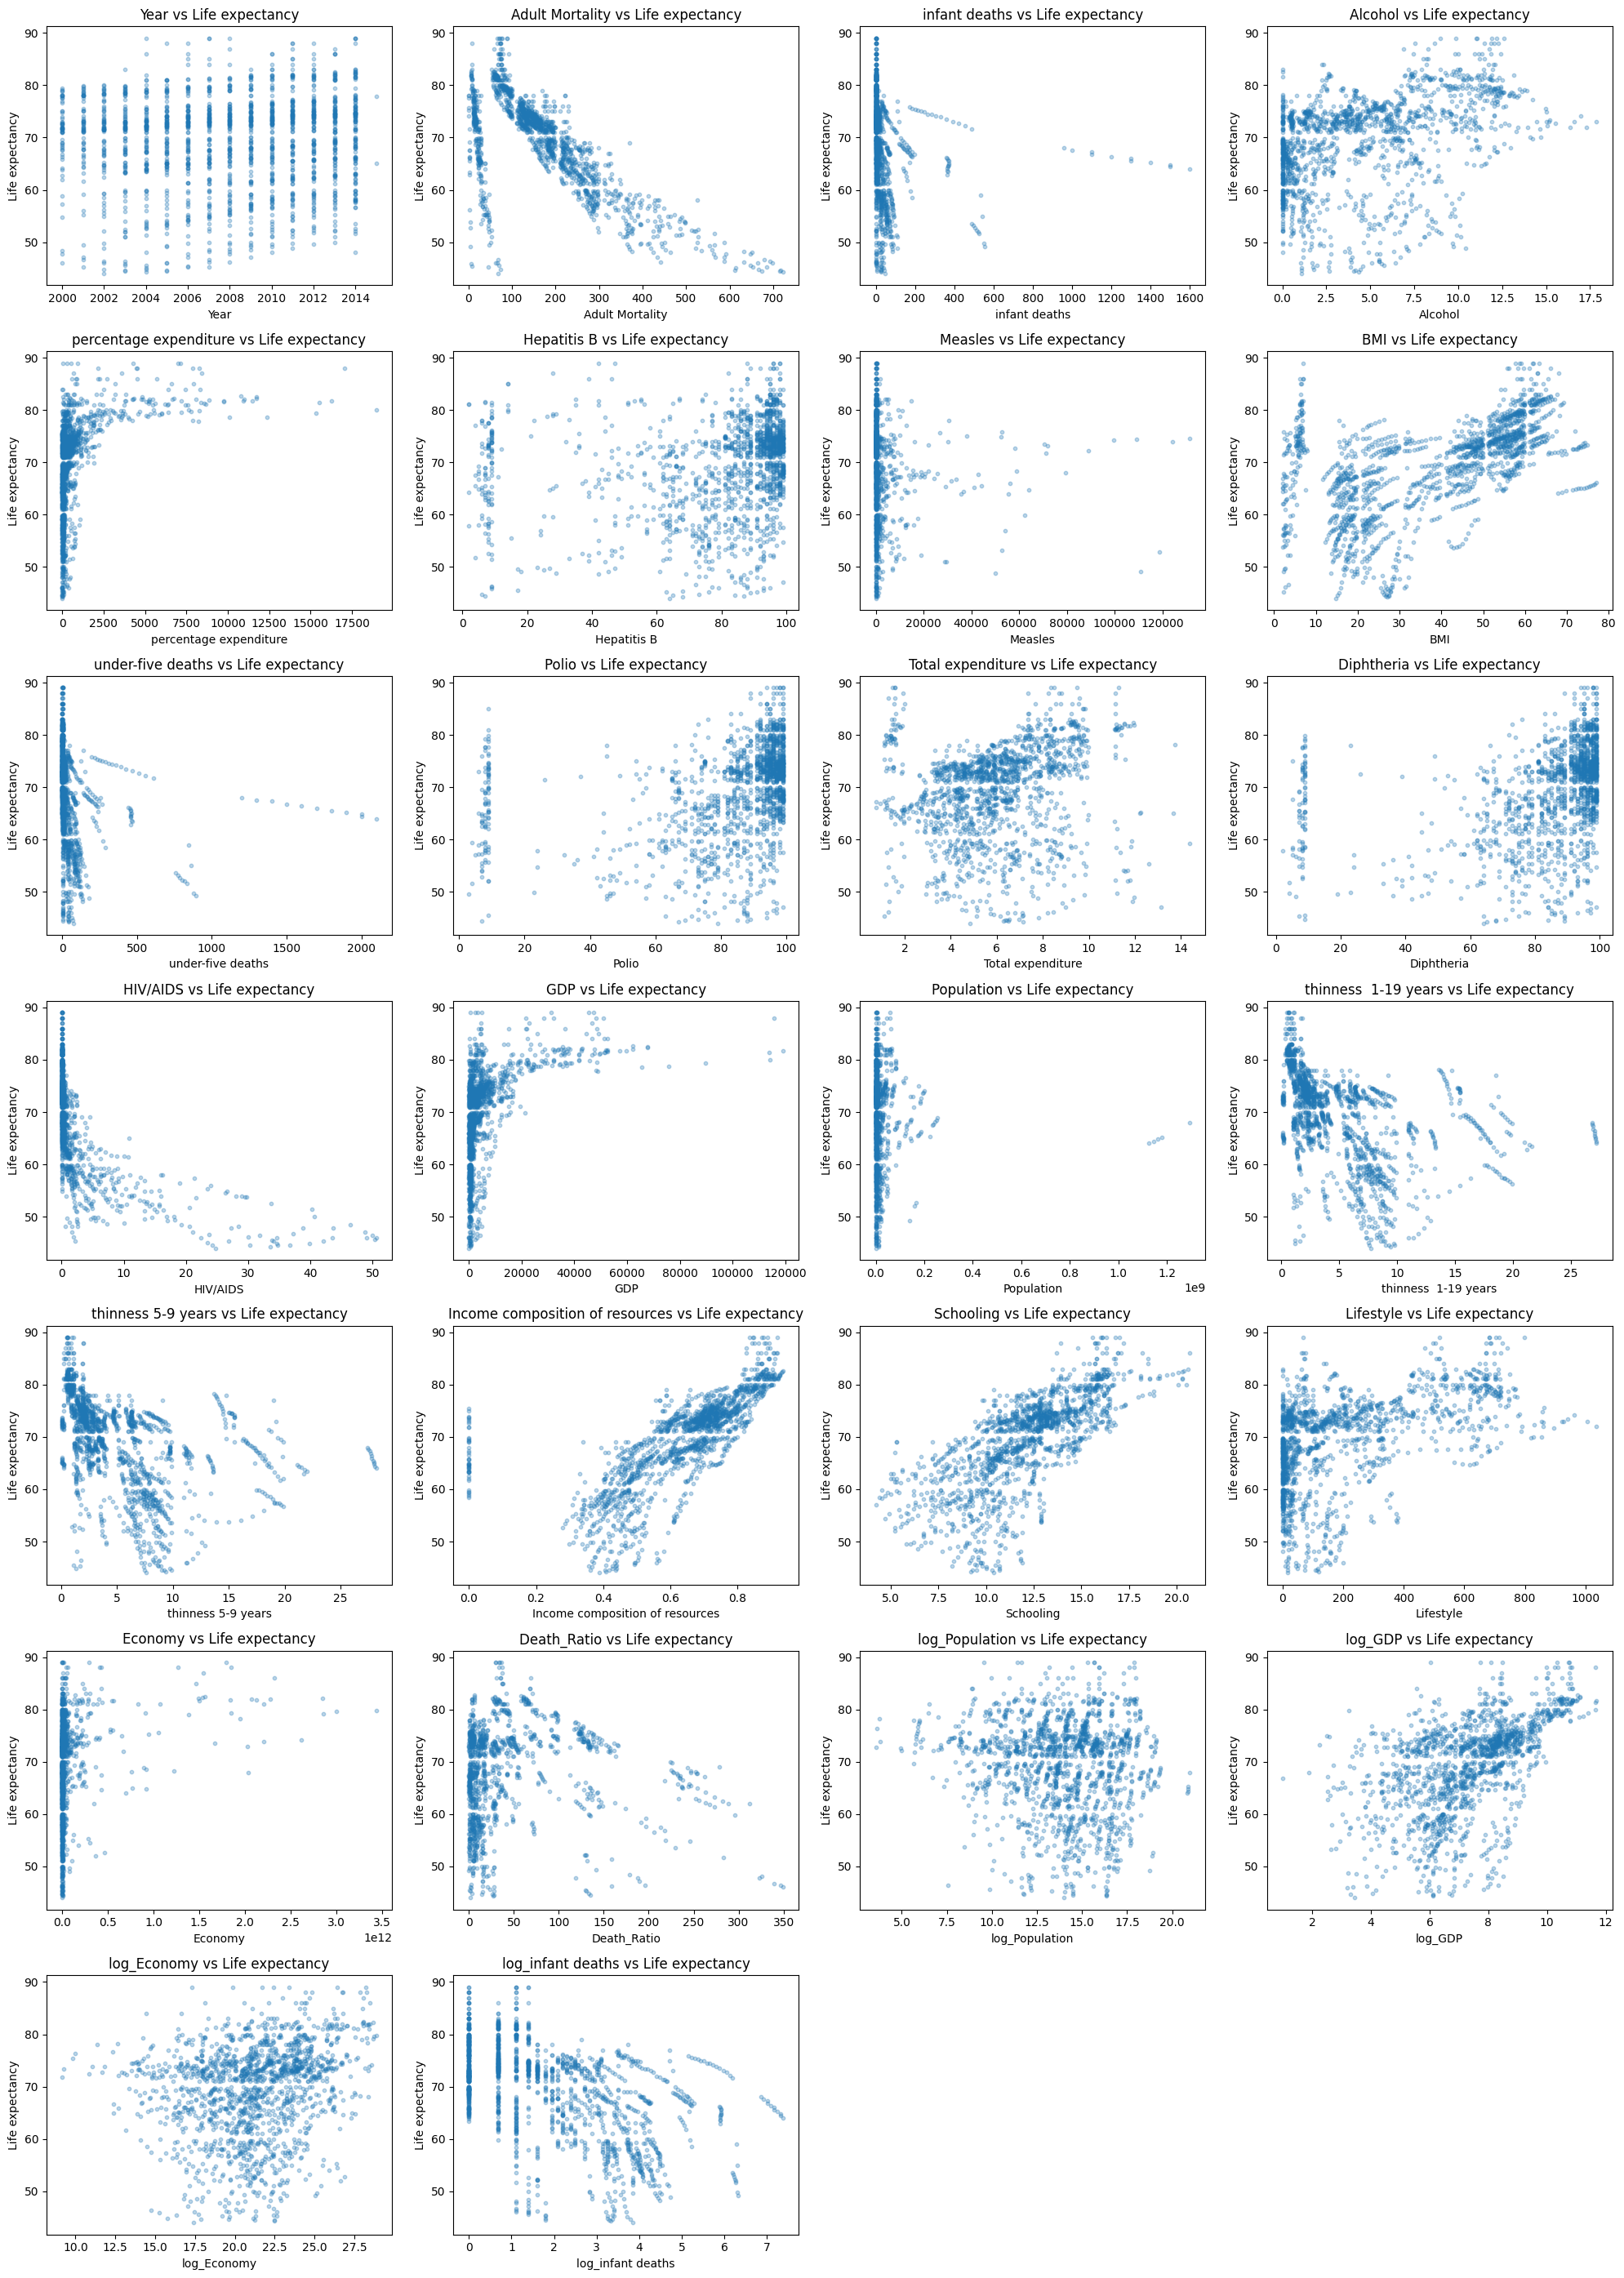

In [526]:
plot_predictors_vs_target(df, target)

## Remove Infinites & Extreme Values

In [527]:
df = remove_rows_with_inf(df, columns_with_inf)


In [528]:
new_check_columns_for_inf = check_columns_for_inf(df)

Positive inf counts:
Year                               0
Life expectancy                    0
Adult Mortality                    0
infant deaths                      0
Alcohol                            0
percentage expenditure             0
Hepatitis B                        0
Measles                            0
BMI                                0
under-five deaths                  0
Polio                              0
Total expenditure                  0
Diphtheria                         0
HIV/AIDS                           0
GDP                                0
Population                         0
thinness  1-19 years               0
thinness 5-9 years                 0
Income composition of resources    0
Schooling                          0
Lifestyle                          0
Economy                            0
Death_Ratio                        0
log_Population                     0
log_GDP                            0
log_Economy                        0
log_infant deaths

In [529]:

test_no_inf_columns(new_check_columns_for_inf)

In [530]:
check_dataset_size_and_shape(df)

Number of rows: 1254
Dataset shape: (1254, 30)
Number of rows (alternative): 1254


## Interquartile Range (IQR-based) Outlier Removal

Why exclude those columns:

Life expectancy (target) — clipping it biases the model; you want to predict the full range, not a trimmed one.

Death_Ratio — created by dividing Adult Mortality / infant deaths. When infant deaths = 0, the result is inf. quantile() on a column with inf values returns inf, so the IQR fence is meaningless.

Log-transform columns (log_Population, etc.) since they're just transformations of columns you're already filtering.



In [531]:

# Columns to skip during outlier removal
exclude = {
    'Life expectancy',       # never clip the target
    # 'Death_Ratio',           # can contain inf (division by zero); IQR breaks on inf
    'log_Population',        # log transform can produce -inf; IQR breaks on -inf
    'log_GDP',               # log transform can produce -inf; IQR breaks on -inf
    'log_Economy',           # log transform can produce -inf; IQR breaks on -inf
    'log_infant deaths',     # log transform can produce -inf; IQR breaks on -inf
}

df = apply_iqr_outlier_removal(df, numeric_cols, exclude)

Rows removed: 998  (1254 → 256)


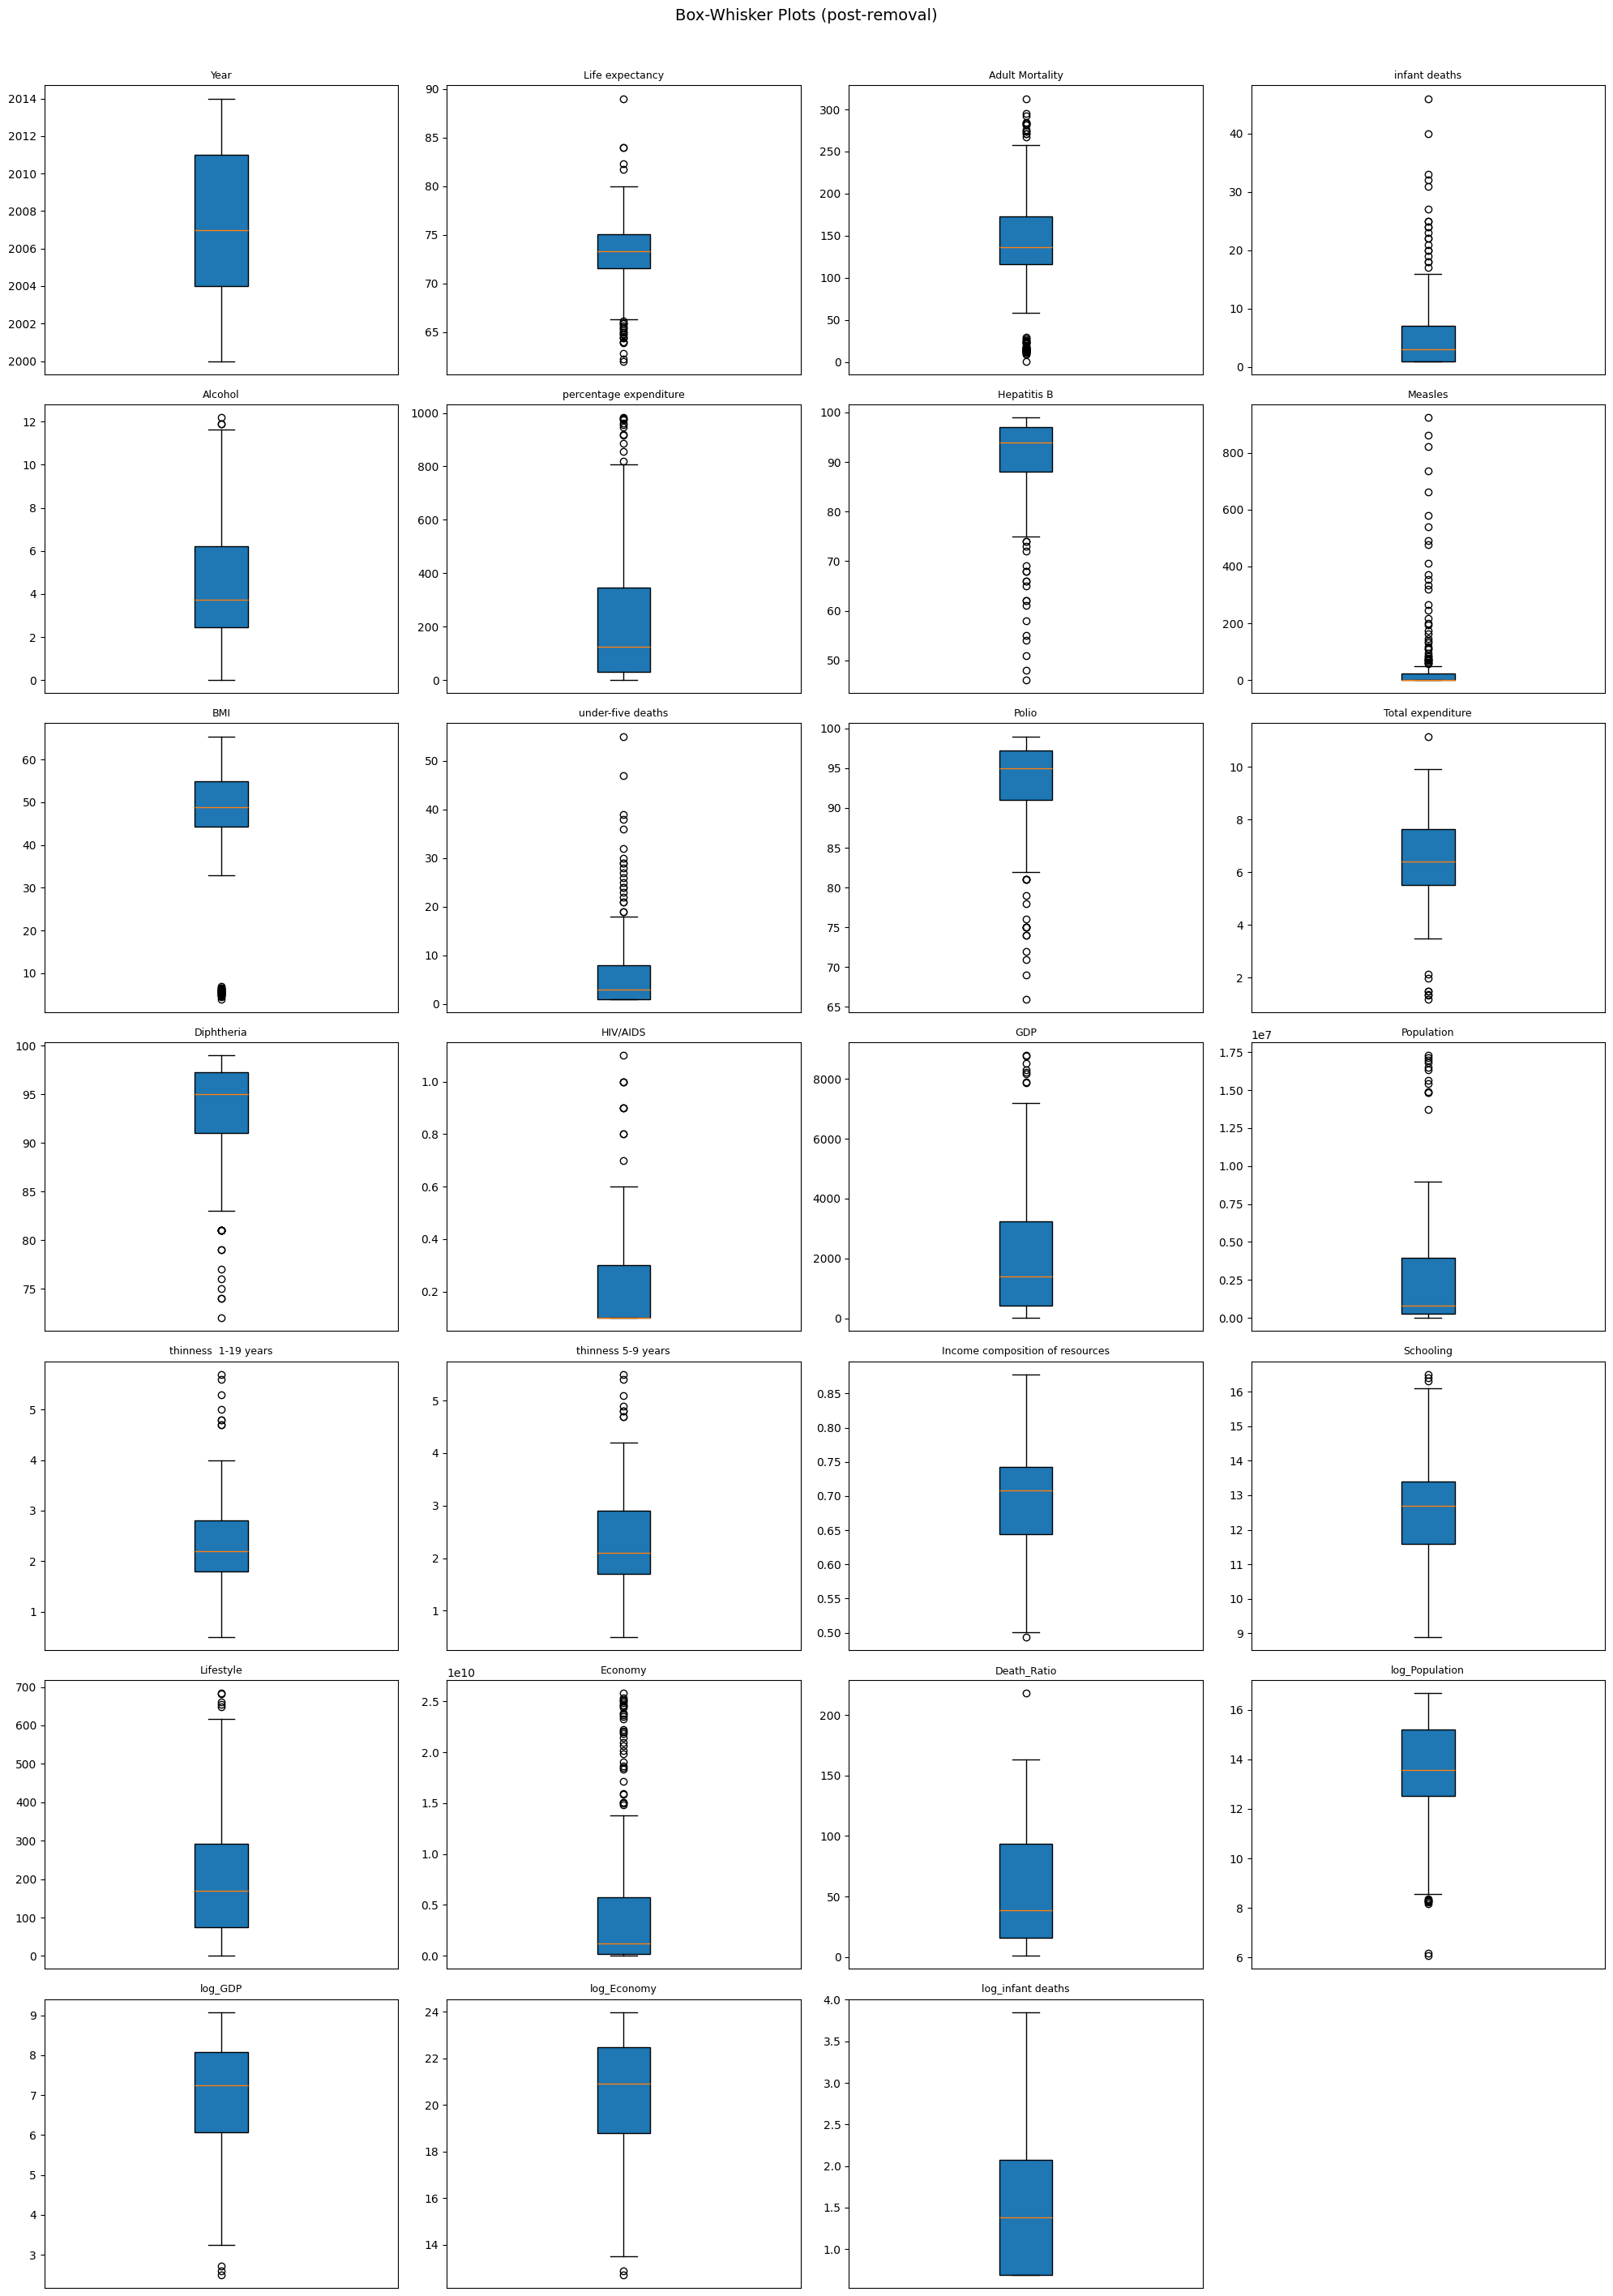

['Year',
 'Life expectancy',
 'Adult Mortality',
 'infant deaths',
 'Alcohol',
 'percentage expenditure',
 'Hepatitis B',
 'Measles',
 'BMI',
 'under-five deaths',
 'Polio',
 'Total expenditure',
 'Diphtheria',
 'HIV/AIDS',
 'GDP',
 'Population',
 'thinness  1-19 years',
 'thinness 5-9 years',
 'Income composition of resources',
 'Schooling',
 'Lifestyle',
 'Economy',
 'Death_Ratio',
 'log_Population',
 'log_GDP',
 'log_Economy',
 'log_infant deaths']

In [532]:
plot_boxplots_of_numeric_features(df, subtitle='Box-Whisker Plots (post-removal)')

## Dimensionality Reduction

Generate a correlation heat map to assess multi-collinearity with the threshold set as 0.75. All variables above 0.75 need to be dropped. 


Principal Component Analysis (PCA): This is the most common approach. It transforms correlated variables into a smaller set of uncorrelated components.

Feature Selection: Dropping one of the highly correlated features to reduce redundancy.

*Applied feature selection.*

### Feature Selection - Non-Multicollinearity

In [533]:

# Upper triangle only — avoids counting each pair twice and self-correlations
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# A column is dropped if it is highly correlated with any earlier column
cols_to_drop = [col for col in upper.columns if (upper[col].abs() > THRESHOLD).any()]

print(f"Columns to be dropped (|corr| > {THRESHOLD}):")
print(cols_to_drop)


Columns to be dropped (|corr| > 0.75):
['under-five deaths', 'GDP', 'thinness 5-9 years', 'Schooling', 'Lifestyle']


In [534]:

df = df.drop(columns=cols_to_drop)
print(f"\nRemaining columns ({len(df.columns)}):")
print(df.columns.tolist())


Remaining columns (25):
['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality', 'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B', 'Measles', 'BMI', 'Polio', 'Total expenditure', 'Diphtheria', 'HIV/AIDS', 'Population', 'thinness  1-19 years', 'Income composition of resources', 'Population Size', 'Economy', 'Death_Ratio', 'log_Population', 'log_GDP', 'log_Economy', 'log_infant deaths']


In [535]:
df.info()

<class 'pandas.DataFrame'>
Index: 256 entries, 21 to 2839
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype   
---  ------                           --------------  -----   
 0   Country                          256 non-null    str     
 1   Year                             256 non-null    int64   
 2   Status                           256 non-null    str     
 3   Life expectancy                  256 non-null    float64 
 4   Adult Mortality                  256 non-null    float64 
 5   infant deaths                    256 non-null    int64   
 6   Alcohol                          256 non-null    float64 
 7   percentage expenditure           256 non-null    float64 
 8   Hepatitis B                      256 non-null    float64 
 9   Measles                          256 non-null    int64   
 10  BMI                              256 non-null    float64 
 11  Polio                            256 non-null    float64 
 12  Total expenditure     

### Feature Selection - Numeric Only

In [540]:
df = df.select_dtypes(include='number')

In [542]:
df.info()

<class 'pandas.DataFrame'>
Index: 256 entries, 21 to 2839
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Year                             256 non-null    int64  
 1   Life expectancy                  256 non-null    float64
 2   Adult Mortality                  256 non-null    float64
 3   infant deaths                    256 non-null    int64  
 4   Alcohol                          256 non-null    float64
 5   percentage expenditure           256 non-null    float64
 6   Hepatitis B                      256 non-null    float64
 7   Measles                          256 non-null    int64  
 8   BMI                              256 non-null    float64
 9   Polio                            256 non-null    float64
 10  Total expenditure                256 non-null    float64
 11  Diphtheria                       256 non-null    float64
 12  HIV/AIDS                         256

In [546]:
test_only_numeric_columns(df)

All columns are numeric.


## Encoding

Skipped in favor of using only numerical features for linear regression. Further analysis can involve determining what correlation categorical features have on target before dropping but this seemed safe for this initial experiment.

# Training

## Train/Test Split

In [547]:
# get pd.Series/Vector for predictors
# ref @ https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.drop.html
# Assumes numeric columns only after dropping non-numeric ones earlier in feature selection
X = df.drop(columns=['Life expectancy'])

# get pd.Series/Vector for target
y = df['Life expectancy']

# split 80/20
# per https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=RANDOM_STATE)


In [548]:
test_train_test_split_ratio(df, X_train, X_test)

Number of rows: 256
Dataset shape: (256, 22)
Number of rows (alternative): 256
Train size: 192, Test size: 64, Test ratio: 25.00%


## Train

In [ ]:

# OLR not covered in module 1 reading or content but found docs for ref @ 
# https://scikit-learn.org/stable/auto_examples/linear_model/plot_ols_ridge.html
regressor = LinearRegression().fit(X_train, y_train)
# y_pred = regressor.predict(X_test)


# Evaluate

Most below is via AI gen using Claude Sonnet 4.6.

## Interpreting MAE and R²

### MAE (Mean Absolute Error)
On average, how many **years off** your predictions are from true life expectancy.

- If `mae = 3.5` → your model's predictions are off by ~3.5 years on average
- Lower is better; 0 = perfect
- Intuitive because it's in the **same units as the target** (years)

### R² (R-squared / Coefficient of Determination)
The **proportion of variance** in life expectancy explained by your features.

$$R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2}$$

| Value | Meaning |
|-------|---------|
| `1.0` | Perfect fit — model explains all variance |
| `0.85` | Model explains 85% of the variance in life expectancy |
| `0.0` | Model is no better than predicting the mean |
| `< 0` | Model is worse than just predicting the mean |

**Rule of thumb for this domain:**
- `r2 > 0.85` → strong model
- `0.65–0.85` → moderate
- `< 0.65` → weak

### Why MAE over MSE here?
Your `evaluate_model` returns both. MAE is more interpretable for life expectancy (years), while MSE penalizes large errors more heavily due to squaring — useful for catching outlier predictions but harder to read intuitively.

## MSE vs RMSE

**MSE (Mean Squared Error)**

$$MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

- Errors are **squared**, so units are years² — not directly interpretable
- Heavily penalizes large errors (outliers have outsized impact)

**RMSE (Root Mean Squared Error)**

$$RMSE = \sqrt{MSE}$$

- Just the square root of MSE — restores units back to **years**
- Still penalizes large errors more than MAE, but is now human-readable

---

### Side-by-side comparison

| | MSE | RMSE |
|---|---|---|
| Units | years² | years |
| Interpretable | No | Yes |
| Penalizes outliers | Yes (heavily) | Yes (moderately) |
| Use case | Optimization / loss functions | Reporting / communication |

### RMSE vs MAE

- **RMSE** will always be ≥ **MAE**
- If they're close → your errors are fairly consistent
- If RMSE >> MAE → a few large errors are inflating RMSE (outlier predictions)

In your `evaluate_model`, RMSE is the more meaningful single number to report because it's in the same units as life expectancy (years) while still being sensitive to large prediction mistakes.

## Interpreting MAPE:

Expressed as a percentage — e.g. mape = 5.2 means predictions are off by ~5.2% of the true life expectancy on average
Lower is better; 0 = perfect
A handy complement to MAE because it's scale-independent (useful if you ever compare models across different datasets)
One caveat: MAPE is undefined if any y_test value is exactly 0. Life expectancy won't be 0, so you're safe here.

One caveat: MAPE is undefined if any y_test value is exactly 0. Life expectancy won't be 0, so you're safe here.

## Actual Eval

In [557]:

def evaluate_model(model, X_test, y_test):
  y_pred = model.predict(X_test)
  
  mse = mean_squared_error(y_test, y_pred)
  rmse = np.sqrt(mse)
  mae = mean_absolute_error(y_test, y_pred)
  r2 = r2_score(y_test, y_pred)
  mape = mean_absolute_percentage_error(y_test, y_pred)

  test_mse = float(round(mse,3))
  test_rmse = float(round(rmse,3))
  test_mae = float(round(mae,3))
  test_r2 = float(round(r2,3))
  test_mape = float(round(mape * 100, 3))  # convert to percentage
  
  # return test_mse, test_mae, test_r2
  return {
    'mse': test_mse,
    'rmse': test_rmse,
    'mae': test_mae,
    'r2': test_r2,
    'mape': test_mape,
  }

metrics = evaluate_model(regressor, X_test, y_test)
print(f"Test MSE: {metrics['mse']}")
print(f"Test RMSE: {metrics['rmse']}")
print(f"Test MAE: {metrics['mae']}")
print(f"Test R²: {metrics['r2']}")
print(f"Test MAPE: {metrics['mape']}%")

Test MSE: 8.465
Test RMSE: 2.91
Test MAE: 1.902
Test R²: 0.505
Test MAPE: 2.717%


## Actual vs. Predicted plot

Actual vs. Predicted Plot (this image): It plots the real values (y) on one axis and the model's predictions (y_hat) on the other. In a perfect model, all points would fall exactly on the diagonal "Perfect fit" line. It's great for seeing how well your model captures the overall trend and scale of the data.

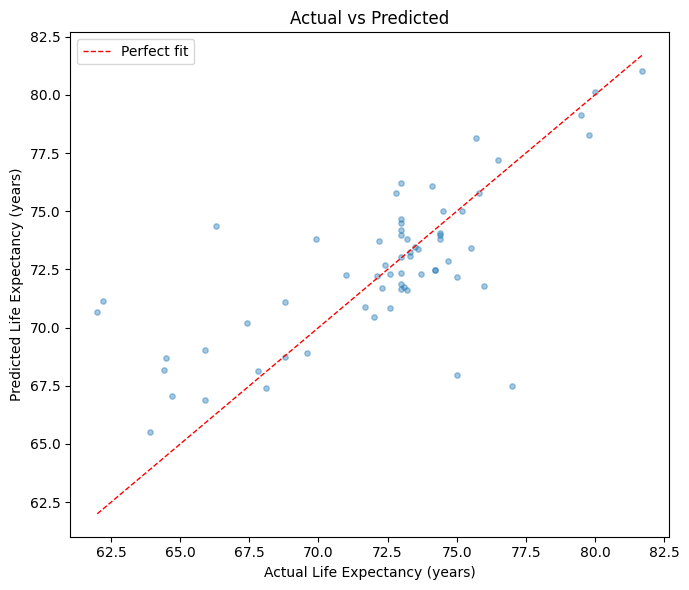

In [559]:
def plot_actual_vs_predicted(model, X_test, y_test):
  y_pred = model.predict(X_test)

  fig, ax = plt.subplots(figsize=(7, 6))
  ax.scatter(y_test, y_pred, alpha=0.4, s=15)

  # Perfect-prediction reference line
  lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
  ax.plot(lims, lims, 'r--', linewidth=1, label='Perfect fit')

  ax.set_xlabel('Actual Life Expectancy (years)')
  ax.set_ylabel('Predicted Life Expectancy (years)')
  ax.set_title('Actual vs Predicted')
  ax.legend()
  plt.tight_layout()
  plt.show()

plot_actual_vs_predicted(regressor, X_test, y_test)

## Residual Scatter Plot

Residual Plot: This plots the errors (Residual = Actual - Predicted) on the vertical axis against either the predicted values or the independent variable on the horizontal axis. A residual plot's center line is always at 
. It is used specifically to check for patterns in errors, like heteroscedasticity or non-linearity.


A **residual scatter plot** shows the difference between actual and predicted values (the **residual** = $y_i - \hat{y}_i$) plotted against either the predicted values or the actual values.

What you built is technically an **Actual vs. Predicted plot**, not a residual plot. The distinction:

| Plot | X-axis | Y-axis |
|------|--------|--------|
| Actual vs. Predicted | Actual $y$ | Predicted $\hat{y}$ |
| Residual plot | Predicted $\hat{y}$ | Residual $y - \hat{y}$ |


**What to look for:**
- **Random scatter around the zero line** → model assumptions are met (good)
- **Funnel shape** → heteroscedasticity; variance of errors grows with prediction size
- **Curved pattern** → a non-linear relationship the model isn't capturing
- **Outliers far from zero** → individual predictions the model got badly wrong

Your current Actual vs. Predicted plot is useful for seeing overall fit, but the residual plot is the standard diagnostic for checking OLS assumptions.

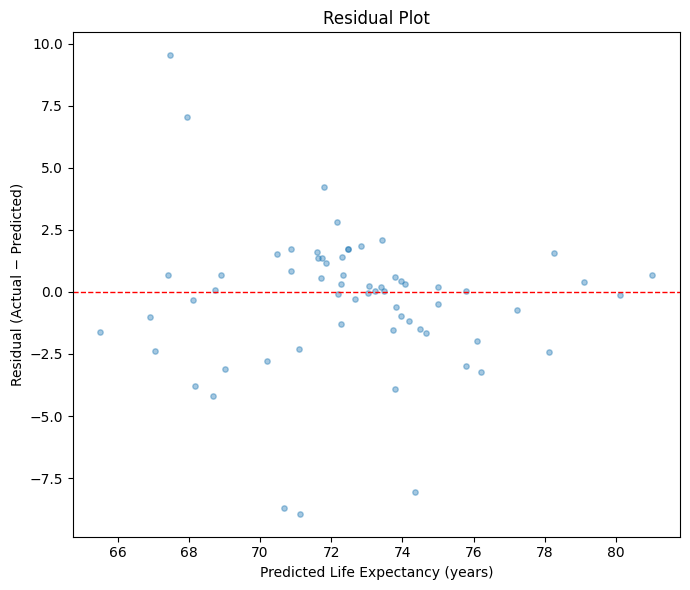

In [561]:

def plot_residuals(model, X_test, y_test):
  y_pred = model.predict(X_test)
  residuals = y_test - y_pred

  fig, ax = plt.subplots(figsize=(7, 6))
  ax.scatter(y_pred, residuals, alpha=0.4, s=15)
  ax.axhline(0, color='r', linestyle='--', linewidth=1)
  ax.set_xlabel('Predicted Life Expectancy (years)')
  ax.set_ylabel('Residual (Actual − Predicted)')
  ax.set_title('Residual Plot')
  plt.tight_layout()
  plt.show()

plot_residuals(regressor, X_test, y_test)

## Residual Histogram

**What to look for:**
- **Symmetric bell shape centered at 0** → residuals are normally distributed (OLS assumption met)
- **Skewed left or right** → the model systematically over- or under-predicts
- **Bimodal or flat** → the model may be missing an important feature or structure in the data

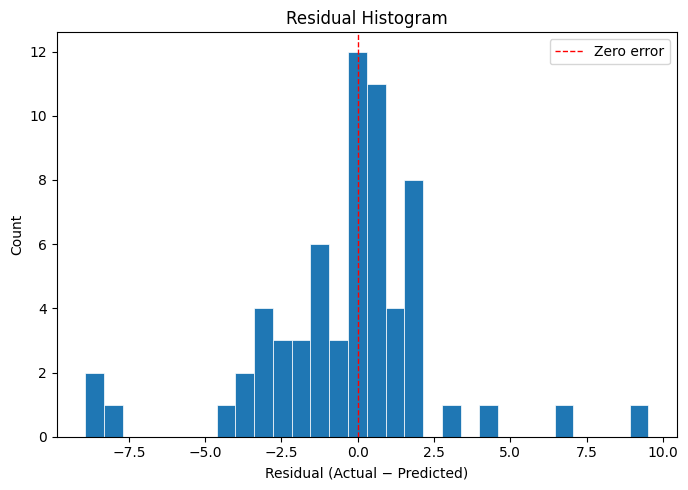

In [562]:
def plot_residual_histogram(model, X_test, y_test, bins: int = 30):
    y_pred = model.predict(X_test)
    residuals = y_test - y_pred

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.hist(residuals, bins=bins, edgecolor='white', linewidth=0.5)
    ax.axvline(0, color='r', linestyle='--', linewidth=1, label='Zero error')
    ax.set_xlabel('Residual (Actual − Predicted)')
    ax.set_ylabel('Count')
    ax.set_title('Residual Histogram')
    ax.legend()
    plt.tight_layout()
    plt.show()

plot_residual_histogram(regressor, X_test, y_test)

## Feature Influence

**This will tell you which features have the largest influence and which you can drop without degrading the model significantly.**

---

**What the current model actually shows:**

| Metric | Value |
|--------|-------|
| R² | 0.505 |
| RMSE | 2.91 years |
| MAE | 1.902 years |

An R² of 0.505 means the current **21 features collectively only explain ~50% of the variance**. Even with all 21, residuals spread ±~6–8 years in the scatter plot.

---

**Why R² is this low — your preprocessing reduced the data significantly:**

The 2nd preprocessing (IQR outlier removal + dropping multicollinear features) likely trimmed the dataset down to ~256 rows (per the `df.info()` output after `select_dtypes`), from the original ~1649. Aggressive IQR removal often discards valid signal along with outliers.

---

**Minimum features to tighten residuals — the practical approach:**

You'd need to run **Recursive Feature Elimination (RFE)** or inspect feature coefficients to find the minimum set. Based on domain knowledge and what this WHO Life Expectancy dataset typically shows, the top predictors are roughly:

1. **`HIV/AIDS`** — single strongest negative predictor
2. **`Income composition of resources`** — HDI proxy, strongest positive predictor
3. **`Adult Mortality`** — strong negative predictor
4. **`Diphtheria`** — immunization, positive predictor
5. **`thinness  1-19 years`** — malnutrition proxy, negative predictor

Research on this dataset typically achieves R² ≈ 0.85–0.90 with **5–7 well-chosen features**, but that requires not over-aggressively removing data.

---


In [563]:
from sklearn.feature_selection import RFE

selector = RFE(LinearRegression(), n_features_to_select=5, step=1)
selector.fit(X_train, y_train)
print(X.columns[selector.support_].tolist())  # minimum selected features

['thinness  1-19 years', 'Income composition of resources', 'log_Population', 'log_GDP', 'log_Economy']
